In [2]:
import random as rd
import pandas as pd
import math

Variant = 20
rd.seed(Variant)
Str1 = 'qwertyuioplkjhgfdsazxcvbnmQWERTYUIOPASDFGHJKLZXCVBNM'
N = rd.randint(20,40)
s1 = ''
for i in range(N):
    s1 += Str1[rd.randint(0, len(Str1)-1)]
D = '!@#$%&*+:;|'[rd.randint(0,10)]
N1 = rd.randint(3,30)
N2 = int(N1 * (N1 + 1) / 2)
if (int(N2/N1) - math.floor(N2/N1)) == 0:
    M = int(N2 / N1)
    K = int(N2 / M)
else:
    M = int(N2 / (N1 + 1))
    K = int(N2 / M)
N4 = rd.randint(123432, 5645634534)
Data  = pd.DataFrame({'Задание':[1,2,3,4,5],'Параметры':['S='+s1,[D, 'N='+str(N2),
                    'M ='+str(M), 'K = '+str(K)],'-','N='+str(N4),'-']})
Data

,Задание,Параметры
0,1,S=dKGuxAlwQQtuoxTSEQhjxGKc
1,2,"[&, N=136, M =8, K = 17]"
2,3,-
3,4,N=4693338485
4,5,-


In [ ]:
format ELF
public _start

section '.data' writeable
    msg db "dKGuxAlwQQtuoxTSEQhjxGKc"
    msg_len = $ - msg
    char_buf db 0
    newline db 0xA

section '.text' executable
_start:
    mov esi, msg_len - 1
    mov edi, msg_len

reverse_loop:
    mov al, [msg + esi]
    mov [char_buf], al

    mov eax, 4
    mov ebx, 1
    mov ecx, char_buf
    mov edx, 1
    int 0x80

    dec esi
    dec edi
    jnz reverse_loop

    mov eax, 4
    mov ebx, 1
    mov ecx, newline
    mov edx, 1
    int 0x80

    mov eax, 1
    xor ebx, ebx
    int 0x80

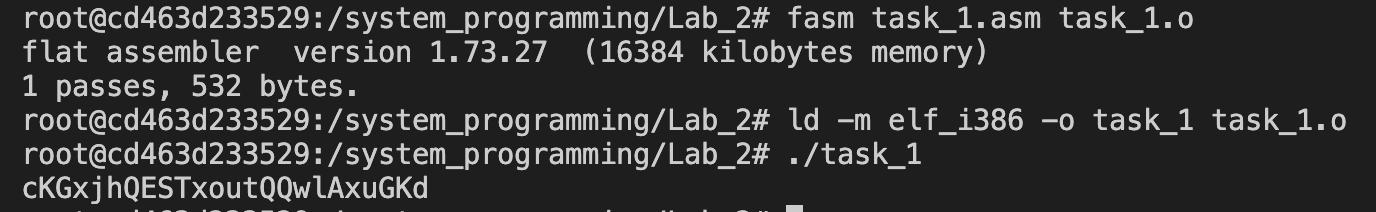

In [ ]:
format ELF
public _start

section '.data' writeable
    ROWS = 8
    COLS = 17
    CHAR = '&'
    buffer db ROWS * COLS dup 0 ; Буфер для заполнения
    newline db 0xA
    char_buf db 0

section '.text' executable
_start:
    ; 1. Заполнение памяти заданным символом
    mov edi, buffer
    mov ecx, ROWS * COLS
    mov al, CHAR
    rep stosb               ; Заполняем буфер

    ; 2. Вывод матрицы
    mov ebp, ROWS           ; Счетчик строк

print_row:
    mov edi, COLS           ; Счетчик столбцов
print_col:
    mov [char_buf], CHAR

    mov eax, 4
    mov ebx, 1
    mov ecx, char_buf
    mov edx, 1
    int 0x80

    dec edi
    jnz print_col

    ; Перевод строки
    mov eax, 4
    mov ebx, 1
    mov ecx, newline
    mov edx, 1
    int 0x80

    dec ebp
    jnz print_row

    ; Завершение
    mov eax, 1
    xor ebx, ebx
    int 0x80

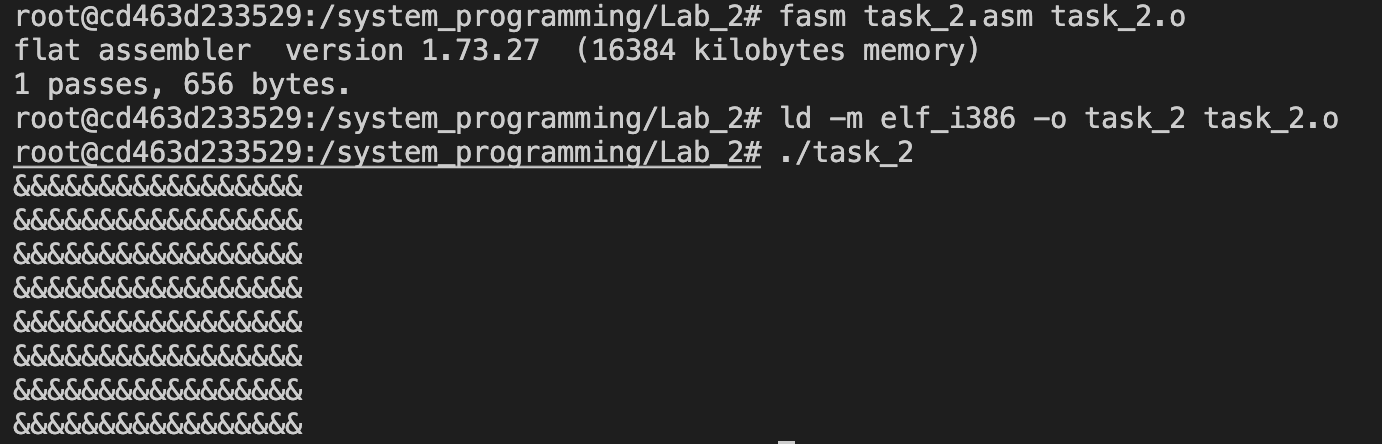

In [ ]:
format ELF
public _start

section '.data' writeable
    K = 136             ; Размер буфера (всего символов)
    CHAR = '&'          ; Заданный символ
    char_buf db 0       ; Буфер для одного символа
    newline db 0xA      ; Символ перевода строки

section '.text' executable
_start:
    mov esi, 0          ; esi = всего выведено символов (наш общий счетчик)
    mov ebp, 1          ; ebp = номер строки (и желаемое кол-во символов в ней)

outer_loop:
    ; Вычисляем, сколько символов вывести в текущей строке
    mov edi, ebp        ; edi = желаемое количество (1, 2, 3...)
    mov eax, esi
    add eax, edi        ; eax = сколько будет всего, если вывести полную строку
    cmp eax, K
    jbe print_full_row  ; Если не превышаем K, выводим полную строку

    ; Иначе (если превышаем), выводим только остаток до конца буфера
    mov edi, K
    sub edi, esi        ; edi = K - esi (ровно столько, сколько осталось)

print_full_row:
    ; Внутренний цикл: вывод символов одной строки
    ; edi используется как счетчик цикла
print_chars:
    mov [char_buf], CHAR

    ; Системный вызов sys_write
    mov eax, 4          ; номер вызова
    mov ebx, 1          ; stdout
    mov ecx, char_buf   ; адрес символа
    mov edx, 1          ; длина = 1 байт
    int 0x80

    inc esi             ; увеличиваем общий счетчик выведенных символов
    dec edi             ; уменьшаем счетчик символов в текущей строке
    jnz print_chars     ; если в строке остались символы, продолжаем

    ; Вывод символа перевода строки после каждой строки треугольника
    mov eax, 4
    mov ebx, 1
    mov ecx, newline
    mov edx, 1
    int 0x80

    ; Проверяем, вывели ли мы ВЕСЬ буфер
    cmp esi, K
    jge done            ; если вывели K символов, завершаем программу

    inc ebp             ; увеличиваем длину следующей строки на 1
    jmp outer_loop      ; переходим к следующей строке

done:
    ; Завершение программы
    mov eax, 1          ; sys_exit
    xor ebx, ebx        ; код возврата 0
    int 0x80

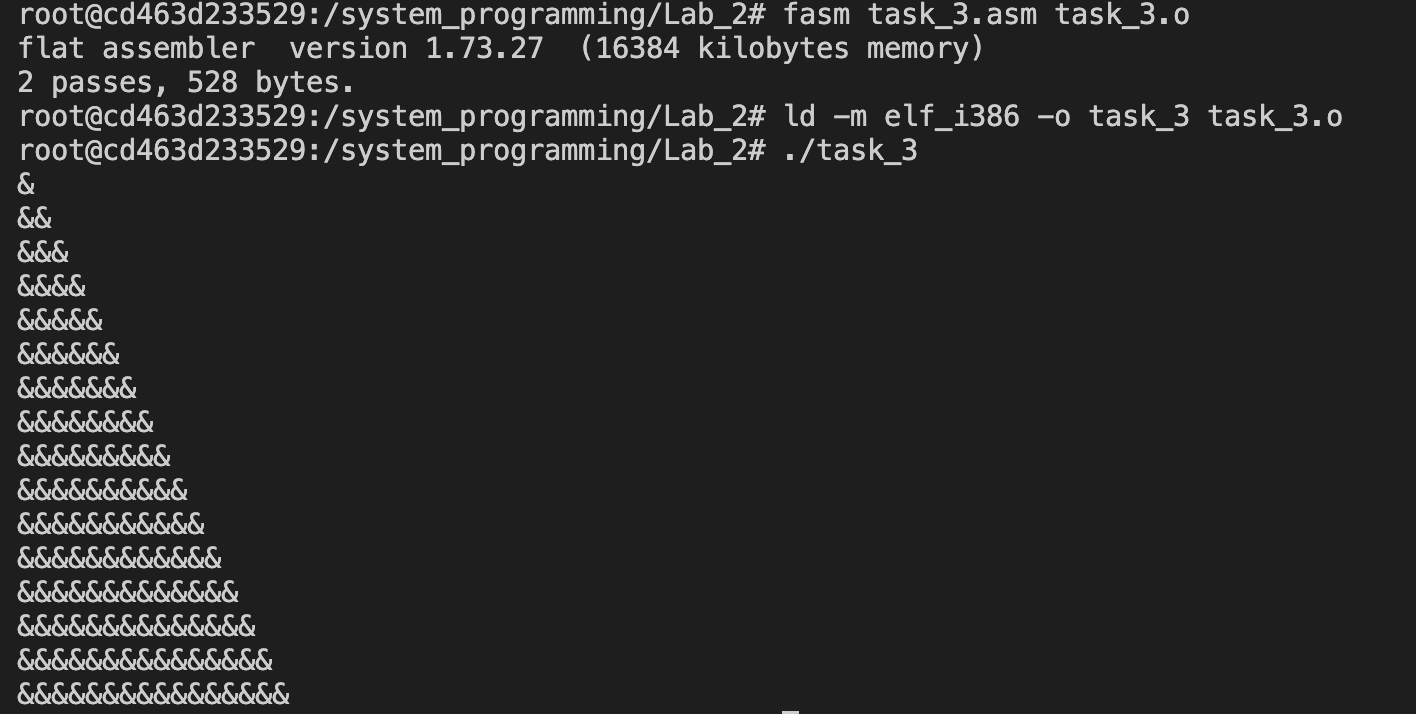

In [ ]:
format ELF
public _start

section '.data' writeable
    num_str db "4693338485", 0   ; Заданное число
    res_str db 16 dup 0     ; Буфер для результата
    newline db 0xA

section '.text' executable
_start:
    ; 1. Подсчет суммы цифр
    mov esi, num_str
    xor ebx, ebx            ; ebx = 0 (сумма)

sum_loop:
    mov al, [esi]
    test al, al
    jz sum_done             ; Конец строки

    sub al, '0'             ; ASCII -> число
    add bl, al
    inc esi
    jmp sum_loop

sum_done:
    ; 2. Преобразование суммы (в bl) в строку
    movzx eax, bl           ; Переносим сумму в eax
    mov edi, res_str + 15   ; Указатель на конец буфера
    mov byte [edi], 0       ; Null-терминатор
    mov cl, 10

conv_loop:
    dec edi
    xor edx, edx
    div ecx                 ; eax = eax / 10, edx = остаток
    add dl, '0'             ; Остаток -> ASCII
    mov [edi], dl
    test eax, eax
    jnz conv_loop

    ; 3. Вывод результата
    mov edx, res_str + 15
    sub edx, edi            ; Вычисляем длину строки

    mov eax, 4
    mov ebx, 1
    mov ecx, edi
    int 0x80

    ; Вывод перевода строки
    mov eax, 4
    mov ebx, 1
    mov ecx, newline
    mov edx, 1
    int 0x80

    ; Завершение
    mov eax, 1
    xor ebx, ebx
    int 0x80

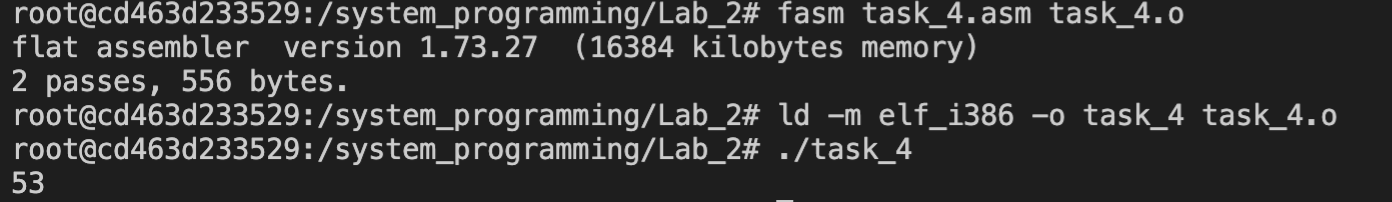

In [ ]:
#include <stdio.h>

int main() {
    char num_str[] = "4693338485";
    int sum = 0;

    for (int i = 0; num_str[i] != '\0'; i++) {
        sum += num_str[i] - '0';
    }

    printf("%d\n", sum);

    return 0;
}

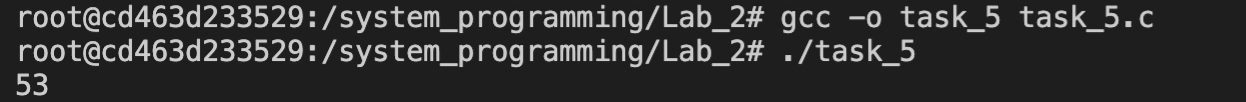